### Projet Maintenance Predictive
## Etape 4 — Evaluation sur l'echantillon de test final

**Regle d'or :** X_test n'a **jamais** ete vu pendant l'entrainement ni le tuning.  
C'est la seule mesure qui compte pour valider le modele en production.

**Fichiers utilises :**
- `models/valve_model.pkl` 
- `data/processed/X_test.csv` — 205 cycles de test
- `data/processed/y_test.csv` — vraies etiquettes de test
- `src/models/evaluate.py` — fonctions d'evaluation


### 1. Imports

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.join(".."))

from src.models.train    import load_model
from src.models.evaluate import (
    print_evaluation_report,
    plot_full_evaluation,
    compute_metrics,
)

print("Imports OK")


Imports OK


### 2. Chargement du modele et des donnees de test

In [2]:
PROCESSED_PATH = os.path.join("..", "data", "processed")
MODELS_PATH    = os.path.join("..", "models")

# Chargement des donnees de test
X_test  = pd.read_csv(os.path.join(PROCESSED_PATH, "X_test.csv"))
y_test  = pd.read_csv(os.path.join(PROCESSED_PATH, "y_test.csv")).squeeze()

# Chargement du modele entraine
model = load_model(os.path.join(MODELS_PATH, "valve_model.pkl"))

print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape} — classes : {y_test.value_counts().to_dict()}")
print(f"Modele  : {type(model.named_steps['clf']).__name__}")


X_test  : (205, 25)
y_test  : (205,) — classes : {0: 132, 1: 73}
Modele  : RandomForestClassifier


### 3. Predictions sur X_test

In [3]:
# Predictions binaires
y_pred = model.predict(X_test)

# Probabilites (pour ROC AUC et courbes)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"Predictions  : {len(y_pred)} cycles")
print(f"Distribution : {pd.Series(y_pred).value_counts().to_dict()}")
print()
print("Exemples (5 premiers cycles) :")
df_preview = pd.DataFrame({
    "y_reel"     : y_test[:5].values,
    "y_pred"     : y_pred[:5],
    "proba_opt"  : y_proba[:5].round(4),
    "correct"    : (y_test[:5].values == y_pred[:5])
})
print(df_preview.to_string(index=False))


Predictions  : 205 cycles
Distribution : {0: 132, 1: 73}

Exemples (5 premiers cycles) :
 y_reel  y_pred  proba_opt  correct
      0       0       0.01     True
      0       0       0.00     True
      0       0       0.00     True
      0       0       0.01     True
      0       0       0.01     True


### 4. Rapport d'evaluation complet

In [4]:
metrics_test = print_evaluation_report(
    y_test, y_pred, y_proba,
    dataset_name="Test final (205 cycles)"
)


  Evaluation sur : Test final (205 cycles)
  Accuracy       : 1.0000
  F1 Score       : 1.0000
  Precision      : 1.0000
  Recall         : 1.0000
  ROC AUC        : 1.0000
  Avg Precision  : 1.0000

  Classification Report :
                 precision    recall  f1-score   support

Non optimal (0)     1.0000    1.0000    1.0000       132
    Optimal (1)     1.0000    1.0000    1.0000        73

       accuracy                         1.0000       205
      macro avg     1.0000    1.0000    1.0000       205
   weighted avg     1.0000    1.0000    1.0000       205



### 5. Comparaison Train vs Test

On compare les performances sur X_train (CV) vs X_test pour detecter un eventuel surapprentissage.


In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, roc_auc_score

# Recharger X_train pour la comparaison
X_train = pd.read_csv(os.path.join(PROCESSED_PATH, "X_train.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_PATH, "y_train.csv")).squeeze()

# CV score sur X_train
cv_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

print("=" * 50)
print("  Comparaison Train (CV) vs Test final")
print("=" * 50)
print(f"  F1 CV  (X_train, 5 folds) : {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
print(f"  F1 Test (X_test final)    : {metrics_test['f1']:.4f}")
print()

gap = abs(cv_f1.mean() - metrics_test['f1'])
print(f"  Ecart CV / Test : {gap:.4f}")
if gap < 0.01:
    print("  => Excellent : pas de surapprentissage")
elif gap < 0.05:
    print("  => Acceptable : leger ecart, modele generalise correctement")
else:
    print("  => Attention : ecart important, risque de surapprentissage")


  Comparaison Train (CV) vs Test final
  F1 CV  (X_train, 5 folds) : 0.9602 (+/- 0.0762)
  F1 Test (X_test final)    : 1.0000

  Ecart CV / Test : 0.0398
  => Acceptable : leger ecart, modele generalise correctement


### 6. Rapport visuel complet

Rapport sauvegarde : evaluation_report.png


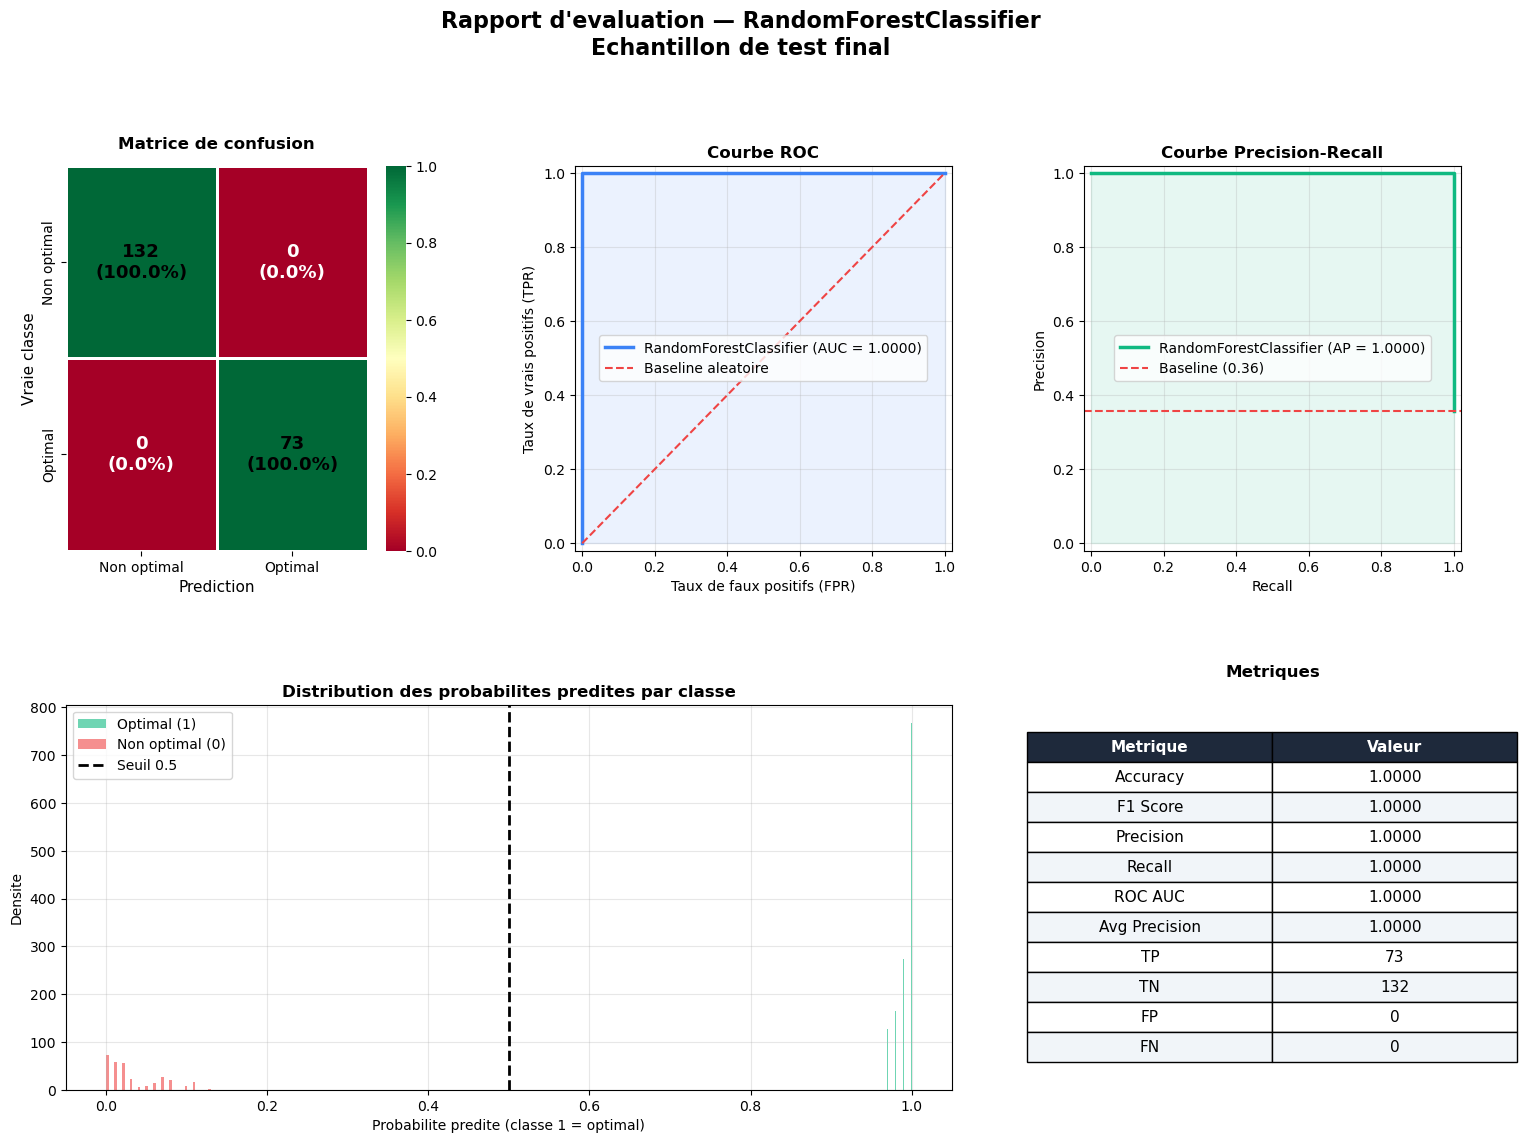

In [6]:
model_name = type(model.named_steps['clf']).__name__

plot_full_evaluation(
    y_true      = y_test,
    y_pred      = y_pred,
    y_proba     = y_proba,
    model_name  = model_name,
    save_path   = "evaluation_report.png"
)


### 7. Analyse des erreurs

On examine les cycles **mal classes** pour comprendre ou le modele echoue.


In [7]:
df_errors = pd.DataFrame({
    "cycle_index" : X_test.index,
    "y_reel"      : y_test.values,
    "y_pred"      : y_pred,
    "proba_opt"   : y_proba.round(4),
}).assign(correct = lambda d: d['y_reel'] == d['y_pred'])

erreurs = df_errors[~df_errors['correct']]
print(f"Cycles mal classes : {len(erreurs)} / {len(df_errors)}")
print(f"Taux d'erreur      : {len(erreurs)/len(df_errors)*100:.2f}%")
print()

if len(erreurs) > 0:
    print("Detail des erreurs :")
    print(erreurs.to_string(index=False))
    print()

    # Types d'erreurs
    fp = len(erreurs[(erreurs['y_reel']==0) & (erreurs['y_pred']==1)])
    fn = len(erreurs[(erreurs['y_reel']==1) & (erreurs['y_pred']==0)])
    print(f"  Faux Positifs (predit Optimal, etait Non optimal) : {fp}")
    print(f"  Faux Negatifs (predit Non optimal, etait Optimal) : {fn}")
    print()
    print("  Interpretation :")
    print(f"  - FP = {fp} : valve OK mais signalement d'alerte inutile")
    print(f"  - FN = {fn} : valve defaillante non detectee (plus critique !)")
else:
    print("Aucune erreur — classification parfaite sur le test final !")


Cycles mal classes : 0 / 205
Taux d'erreur      : 0.00%

Aucune erreur — classification parfaite sur le test final !


## 8. Conclusion

| Metrique | Valeur attendue | Interpretation |
|----------|----------------|----------------|
| Accuracy | > 95% | Taux de bonne classification global |
| F1 Score | > 95% | Equilibre precision/rappel |
| ROC AUC  | > 0.99 | Capacite de discrimination |
| Faux Negatifs | Minimiser | Valve defaillante non detectee = risque industriel |

### Contexte industriel
Dans un systeme de maintenance predictive, les **Faux Negatifs** sont les plus critiques :  
ne pas detecter une valve defaillante peut provoquer un arret machine ou un accident.  
On pourrait abaisser le seuil de classification (< 0.5) pour privilegier le Recall.

### Prochaine etape
Le modele valide est pret pour :
- **Etape 5** : API FastAPI (`src/api/app.py`)
- **Etape 6** : Containerisation Docker
- **Etape 7** : Tests unitaires + CI/CD
